In [9]:
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import sys
import seaborn as sns
import nbimporter
from read_plot_voxelization import  export_filtered_las, show_voxelgrid_plotly, point_cloud_to_dataframe

### PCD to JPG for semantic segmentation 

In [10]:
las_path  = "../datasource/2025-08-19-MS.laz"
df = point_cloud_to_dataframe(las_path)

print(df.head())
print(df.columns)

📂 Loading LAS/LAZ file: ../datasource/2025-08-19-MS.laz
Number of points: 30,706,449
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'confidence', 'normal x', 'normal y', 'normal z']
Applied LAS header scale+offset to X,Y,Z.
DataFrame created. Shape: (30706449, 26)
           X          Y       Z  intensity  return_number  number_of_returns  \
0  13.614034  45.271286  41.081          0              1                  1   
1  13.614034  45.271286  41.081          0              1                  1   
2  13.614034  45.271286  41.081          0              1                  1   
3  13.614034  45.271286  41.081          0              1                  1   
4  13.614034  45.271286  41.081          0              1                

In [11]:
import numpy as np

target_pixels = 2000 * 2000  # e.g. 4 million pixels
xs = df["X"].to_numpy(dtype=float)
ys = df["Y"].to_numpy(dtype=float)
zs = df["Z"].to_numpy(dtype=float)

xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()

dx = xmax - xmin
dy = ymax - ymin

# 2) Compute cell area so that dx*dy / cell_area ≈ target_pixels
area = dx * dy
cell_area = area / target_pixels

# 3) Resolution is sqrt(cell_area)
res = np.sqrt(cell_area)
print("Suggested resolution:", res)

res = 400 # grid resolution in same units as X,Y 

Suggested resolution: 8.327731472165535e-07


##### Compute grid cell indices i, j for each point

In [12]:
xs = df["X"].to_numpy(dtype=float)
ys = df["Y"].to_numpy(dtype=float)
zs = df["Z"].to_numpy(dtype=float)  # used later for height raster

xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()

width  = int(np.floor((xmax - xmin) / res)) + 1
height = int(np.floor((ymax - ymin) / res)) + 1

# column index (i), row index (j) for each point
i = np.floor((xs - xmin) / res).astype(int)  # 0 .. width-1
j = np.floor((ys - ymin) / res).astype(int)  # 0 .. height-1

##### Build a raster (example: max Z per cell → canopy height)

In [13]:
z_raster = np.full((height, width), -np.inf, dtype=float)

for k in range(len(zs)):
    r = j[k]
    c = i[k]
    z_raster[r, c] = max(z_raster[r, c], zs[k])

z_raster[z_raster == -np.inf] = np.nan


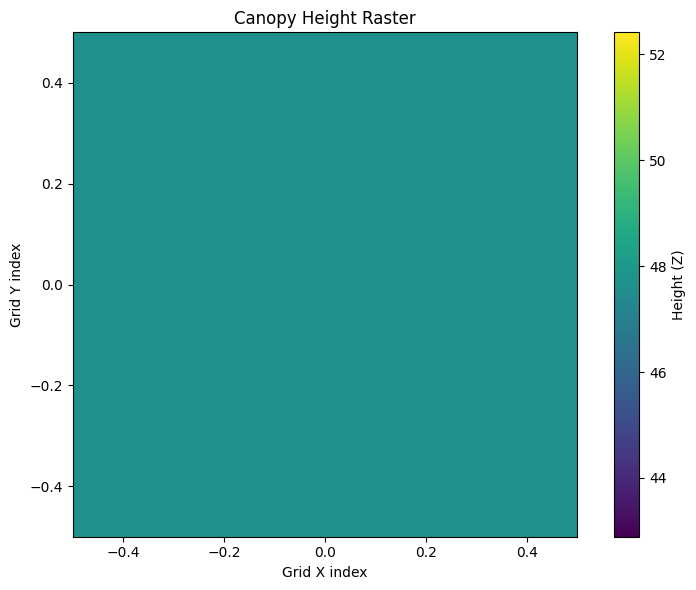

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# z_raster is your 2D array from before (shape: [height, width])

plt.figure(figsize=(8, 6))
im = plt.imshow(z_raster, origin="lower")  #Y increases upwards
plt.colorbar(im, label="Height (Z)")
plt.title("Canopy Height Raster")
plt.xlabel("Grid X index")
plt.ylabel("Grid Y index")
plt.tight_layout()
plt.show()


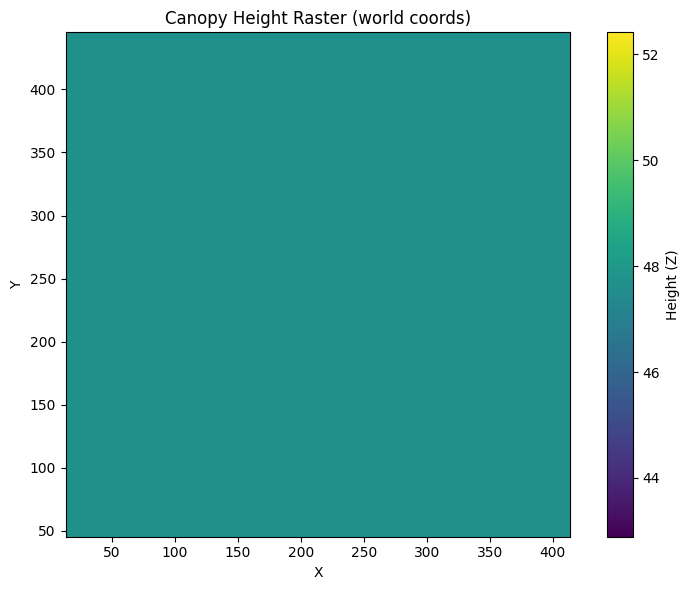

In [15]:
xmin, ymin = xs.min(), ys.min()  # from earlier

extent = [xmin, xmin + res * z_raster.shape[1],
          ymin, ymin + res * z_raster.shape[0]]

plt.figure(figsize=(8, 6))
im = plt.imshow(z_raster, origin="lower", extent=extent)
plt.colorbar(im, label="Height (Z)")
plt.title("Canopy Height Raster (world coords)")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
from PIL import Image

z = z_raster.copy()

nan_mask = np.isnan(z)
z[nan_mask] = 0.0

valid = ~nan_mask
z_min = z[valid].min()
z_max = z[valid].max()

if z_max > z_min:
    z_norm = (z - z_min) / (z_max - z_min)
else:
    z_norm = np.zeros_like(z)

# Scale to 0–255 and convert -> uint8
img_gray = (z_norm * 255).astype(np.uint8)     # shape: (H, W)

img_rgb = np.stack([img_gray, img_gray, img_gray], axis=-1)  # shape: (H, W, 3)

img_pil = Image.fromarray(img_rgb)
img_pil.save("chm_olive_field.png")


### Steps
Split point cloud into tiles (e.g. 50mx50m)
Generate raster per tile
Normalize data if need
Train semantic segmentation neural net 
Convert back to real-world coordinates
Aggregate result acros files